In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import optuna
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from src.data import load_csv_df
from src.plotting import set_plotting_style

C:\Users\User\Desktop\ML\Wikipedia-Country-Statictics-2026-Clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Already prepared accent palette applying using function from mine src module (plotting)
set_plotting_style()
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
DF_PATH = "../data/processed/pca_df.csv"

# Safely loading dataframe using function from mine src module (data)
X_pca_df = load_csv_df(
    df_path=DF_PATH,
)

Successfully loaded dataframe: ..\data\processed\pca_df.csv
Dataframe has: 195 rows / 3 columns
Dataframe size: 0.005MB


In [4]:
"""Comparative clustering optimization (optuna)
-----------------------------------------------------
1. Objective & metrics:
    - Optimize hyperparameters for comparative clustering (K-means, DBSCAN, HDBSCAN).
    - Maximize Silhouette score as primary metric to ensure groups.
    - Track Davies-Bouldin and Calinski-Harabasz scores for quantitative validation.

2. Quality & validation:
    - Minimal cluster size (n >= 3): Reject micro-clusters with < 3 countries to
    avoid isolating single outlier nations.
    - Max noise threshold (<= 20%): Limit unclassified noise points in DBSCAN/HDBSCAN
    so we don't lose too many countries from analysis.

3. Experiment tracking:
    - Log all hyperparameter combinations and trial statuses via trial.set_user_attr().
    - Export results to Pandas DataFrames for quick cross-algorithm comparisons.
"""

def objective_kmeans(trial: optuna.Trial) -> float:
    n_clusters = trial.suggest_int("n_clusters", 2, 10)
    init = trial.suggest_categorical("init", ["random", "k-means++"])
    n_init = trial.suggest_int("n_init", 10, 20)
    algorithm = trial.suggest_categorical("algorithm", ["lloyd", "elkan"])

    model = KMeans(
        n_clusters=n_clusters,
        init=init,
        n_init=n_init,
        algorithm=algorithm,
        random_state=42
    )
    labels = model.fit_predict(X_pca_df)

    cluster_sizes = pd.Series(labels).value_counts()
    min_cluster_size = int(cluster_sizes.min())
    max_cluster_size = int(cluster_sizes.max())

    trial.set_user_attr("min_cluster_size", min_cluster_size)
    trial.set_user_attr("max_cluster_size", max_cluster_size)

    if min_cluster_size < 3:
        trial.set_user_attr("status", "Rejected (<3 members)")
        return -1

    score = silhouette_score(X_pca_df, labels)
    db_score = davies_bouldin_score(X_pca_df, labels)
    ch_score = calinski_harabasz_score(X_pca_df, labels)

    trial.set_user_attr("davies_bouldin", db_score)
    trial.set_user_attr("calinski_harabasz", ch_score)
    trial.set_user_attr("status", "Accepted")

    return score


study_kmeans = optuna.create_study(direction="maximize")
study_kmeans.optimize(
    objective_kmeans,
    n_trials=50,
    show_progress_bar=True
)

print("=" * 50)
print(f"Best silhouette score: {study_kmeans.best_value:.4f}")
print("Best hyperparameters:")
for key, value in study_kmeans.best_params.items():
    print(f"  - {key}: {value}")
print("=" * 50)

df_kmeans_results = study_kmeans.trials_dataframe()

cols = [
    "number", "value", "params_n_clusters", "params_init",
    "params_algorithm", "user_attrs_davies_bouldin",
    "user_attrs_min_cluster_size", "user_attrs_status"
]

df_kmeans_summary = df_kmeans_results[cols].sort_values(by="value", ascending=False).reset_index(drop=True)
display(df_kmeans_summary.head(10))

best_kmeans = KMeans(
    **study_kmeans.best_params,
    random_state=42
)
X_pca_df["kmeans_cluster"] = best_kmeans.fit_predict(X_pca_df)

Best trial: 0. Best value: 0.387798: 100%|██████████| 50/50 [00:02<00:00, 19.29it/s]


Best silhouette score: 0.3878
Best hyperparameters:
  - n_clusters: 2
  - init: random
  - n_init: 11
  - algorithm: lloyd


,number,value,params_n_clusters,params_init,params_algorithm,user_attrs_davies_bouldin,user_attrs_min_cluster_size,user_attrs_status
0,0,0.387798,2,random,lloyd,0.959597,37,Accepted
1,1,0.387798,2,random,elkan,0.959597,37,Accepted
2,8,0.387798,2,k-means++,elkan,0.959597,37,Accepted
3,17,0.387798,2,random,lloyd,0.959597,37,Accepted
4,15,0.387798,2,random,lloyd,0.959597,37,Accepted
5,11,0.387798,2,random,elkan,0.959597,37,Accepted
6,46,0.387798,2,random,lloyd,0.959597,37,Accepted
7,48,0.387798,2,k-means++,lloyd,0.959597,37,Accepted
8,45,0.387798,2,random,lloyd,0.959597,37,Accepted
9,49,0.387798,2,random,elkan,0.959597,37,Accepted


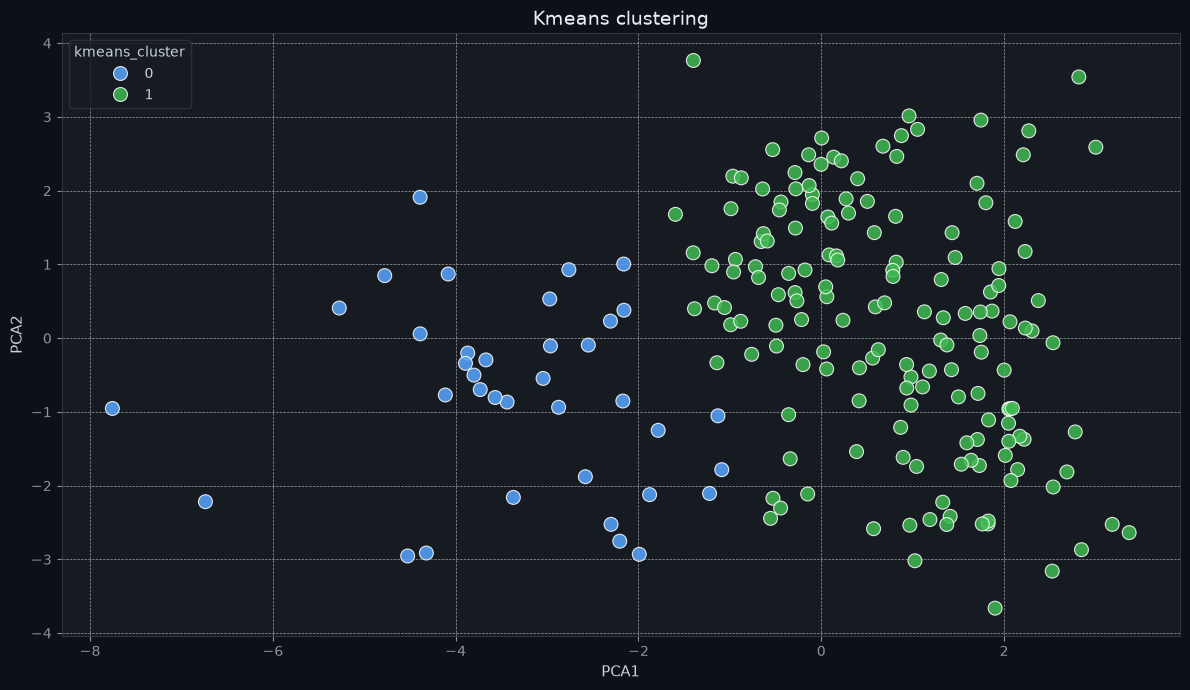

In [5]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=X_pca_df,
    x="PCA1",
    y="PCA2",
    hue="kmeans_cluster",
    s=100,
    alpha=0.85
)
plt.title("Kmeans clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

In [6]:
def objective_dbscan(trial: optuna.Trial) -> float:
    eps = trial.suggest_float("eps", 0.1, 2.0, step=0.05)
    min_samples = trial.suggest_int("min_samples", 3, 12)
    metric = trial.suggest_categorical(
        "metric", ["euclidean", "manhattan", "cosine"]
    )

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric=metric
    )
    labels = model.fit_predict(X_pca_df)

    n_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_ration = np.sum(labels == -1) / len(labels)

    trial.set_user_attr("n_clusters", n_clusters)
    trial.set_user_attr("noise_ratio", round(noise_ration, 3))

    if n_clusters < 2:
        trial.set_user_attr("status", "Rejected (<2 members)")
        return -1

    if noise_ration > 0.2:
        trial.set_user_attr("status", "Rejected (>20 noise)")
        return -1

    mask = labels != -1
    score = silhouette_score(X_pca_df[mask], labels[mask])
    db_score = davies_bouldin_score(X_pca_df[mask], labels[mask])
    ch_score = calinski_harabasz_score(X_pca_df[mask], labels[mask])

    trial.set_user_attr("davies_bouldin", db_score)
    trial.set_user_attr("calinski_harabasz", ch_score)
    trial.set_user_attr("status", "Accepted")

    return score


study_dbscan = optuna.create_study(direction="maximize")
study_dbscan.optimize(
    objective_dbscan,
    n_trials=50,
    show_progress_bar=True
)

print("=" * 50)
print(f"Best silhouette score: {study_dbscan.best_value:.4f}")
print("Best hyperparameters:")
for key, value in study_dbscan.best_params.items():
    print(f"  - {key}: {value}")
print("=" * 50)

df_dbscan_results = study_dbscan.trials_dataframe()

cols = [
    "number", "value", "params_eps", "params_min_samples",
    "params_metric", "user_attrs_n_clusters",
    "user_attrs_noise_ratio", "user_attrs_davies_bouldin",
    "user_attrs_calinski_harabasz"
]

df_dbscan_summary = df_dbscan_results[cols].sort_values(by="value", ascending=False).reset_index(drop=True)
display(df_dbscan_summary.head(10))

best_dbscan = DBSCAN(**study_dbscan.best_params)
X_pca_df["dbscan_cluster"] = best_dbscan.fit_predict(X_pca_df)

Best trial: 47. Best value: 0.43236: 100%|██████████| 50/50 [00:00<00:00, 107.02it/s] 


Best silhouette score: 0.4324
Best hyperparameters:
  - eps: 1.8000000000000003
  - min_samples: 9
  - metric: manhattan


,number,value,params_eps,params_min_samples,params_metric,user_attrs_n_clusters,user_attrs_noise_ratio,user_attrs_davies_bouldin,user_attrs_calinski_harabasz
0,47,0.432360,1.80,9,manhattan,2,0.200,0.717024,73.731884
1,38,0.415927,1.35,11,euclidean,2,0.174,0.743263,72.547944
2,13,0.414727,1.35,10,euclidean,2,0.164,0.752574,74.705957
3,32,0.414727,1.35,10,euclidean,2,0.164,0.752574,74.705957
4,9,0.408939,1.45,12,euclidean,2,0.123,0.760579,76.583703
5,49,0.408617,2.00,10,manhattan,2,0.159,0.787656,75.273973
6,43,0.408492,1.40,11,euclidean,2,0.144,0.753994,73.749954
7,41,0.408492,1.40,11,euclidean,2,0.144,0.753994,73.749954
8,15,0.407625,1.50,12,euclidean,2,0.118,0.751866,73.937944
9,17,0.401736,1.45,10,euclidean,2,0.103,0.813192,81.839297


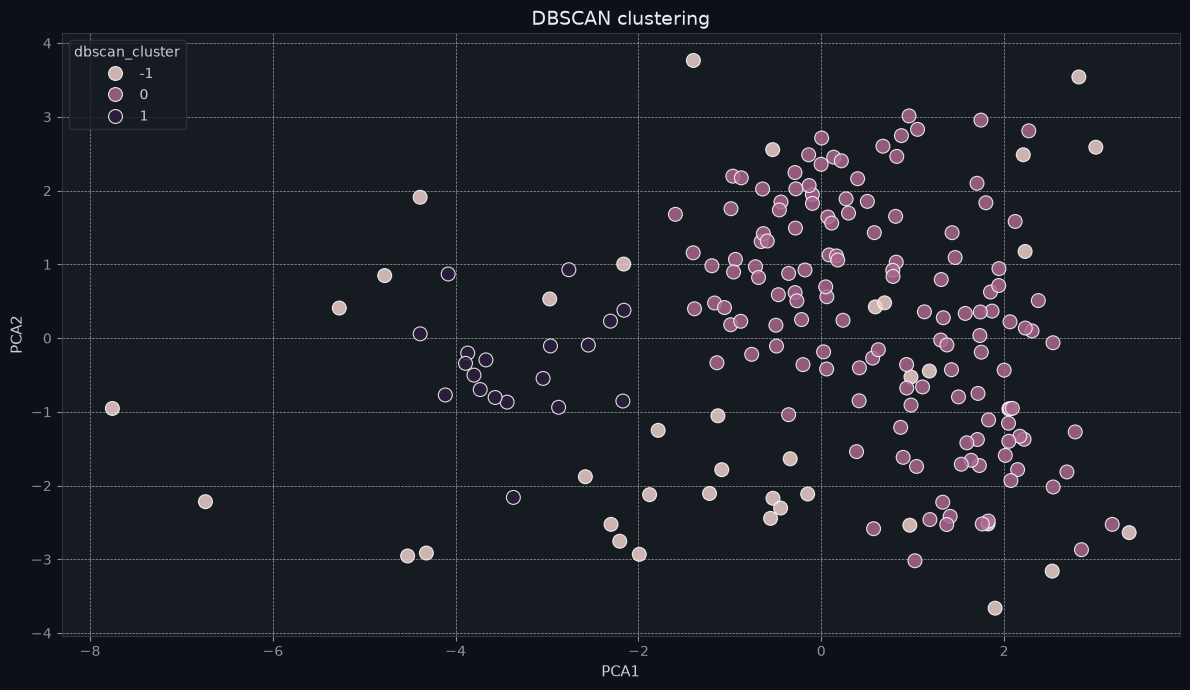

In [7]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=X_pca_df,
    x="PCA1",
    y="PCA2",
    hue="dbscan_cluster",
    s=100,
    alpha=0.85
)
plt.title("DBSCAN clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

In [8]:
def objective_hdbscan(trial: optuna.Trial) -> float:
    min_cluster_size = trial.suggest_int("min_cluster_size", 3, 15)
    min_samples = trial.suggest_int("min_samples", 1, 10)
    metric = trial.suggest_categorical(
        "metric", ["euclidean", "manhattan"]
    )

    model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric
    )
    labels = model.fit_predict(X_pca_df)

    n_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_ratio = np.sum(labels == -1) / len(labels)

    trial.set_user_attr("n_clusters", n_clusters)
    trial.set_user_attr("noise_ratio", noise_ratio)

    if n_clusters < 2:
        trial.set_user_attr("status", "Rejected (<2 members)")
        raise optuna.TrialPruned()

    if noise_ratio > 0.2:
        trial.set_user_attr("status", "Rejected (>20 noise)")
        raise optuna.TrialPruned()

    mask = labels != -1
    score = silhouette_score(X_pca_df[mask], labels[mask])
    db_score = davies_bouldin_score(X_pca_df[mask], labels[mask])
    ch_score = calinski_harabasz_score(X_pca_df[mask], labels[mask])

    trial.set_user_attr("davies_bouldin", db_score)
    trial.set_user_attr("calinski_harabasz", ch_score)
    trial.set_user_attr("status", "Accepted")

    return score


study_hdbscan = optuna.create_study(direction="maximize")
study_hdbscan.optimize(
    objective_hdbscan,
    n_trials=50,
    show_progress_bar=True
)

print("=" * 50)
print(f"Best silhouette score: {study_hdbscan.best_value:.4f}")
print("Best hyperparameters:")
for key, value in study_hdbscan.best_params.items():
  print(f"  - {key}: {value}")
print("=" * 50)

df_hdbscan_results = study_hdbscan.trials_dataframe()

cols = [
    "number", "value", "params_min_cluster_size",
    "params_min_samples", "params_metric", "user_attrs_n_clusters",
    "user_attrs_noise_ratio", "user_attrs_davies_bouldin", "user_attrs_calinski_harabasz",
]

df_hdbscan_summary = df_hdbscan_results[cols].sort_values(by="value", ascending=False).reset_index(drop=True)
display(df_hdbscan_summary.head(10))

best_hdbscan = HDBSCAN(**study_hdbscan.best_params)
X_pca_df["hdbscan_cluster"] = best_hdbscan.fit_predict(X_pca_df)

Best trial: 2. Best value: 0.420225: 100%|██████████| 50/50 [00:01<00:00, 47.41it/s]

Best silhouette score: 0.4202
Best hyperparameters:
  - min_cluster_size: 11
  - min_samples: 8
  - metric: euclidean


,number,value,params_min_cluster_size,params_min_samples,params_metric,user_attrs_n_clusters,user_attrs_noise_ratio,user_attrs_davies_bouldin,user_attrs_calinski_harabasz
0,2,0.420225,11,8,euclidean,2,0.189744,0.710204,64.152856
1,31,0.420225,10,8,euclidean,2,0.189744,0.710204,64.152856
2,32,0.420225,8,8,euclidean,2,0.189744,0.710204,64.152856
3,36,0.420225,13,8,euclidean,2,0.189744,0.710204,64.152856
4,41,0.420225,5,8,euclidean,2,0.189744,0.710204,64.152856
5,44,0.420225,10,8,euclidean,2,0.189744,0.710204,64.152856
6,21,0.420225,10,8,euclidean,2,0.189744,0.710204,64.152856
7,16,0.420225,8,8,euclidean,2,0.189744,0.710204,64.152856
8,17,0.420225,8,8,euclidean,2,0.189744,0.710204,64.152856
9,47,0.420225,9,8,euclidean,2,0.189744,0.710204,64.152856


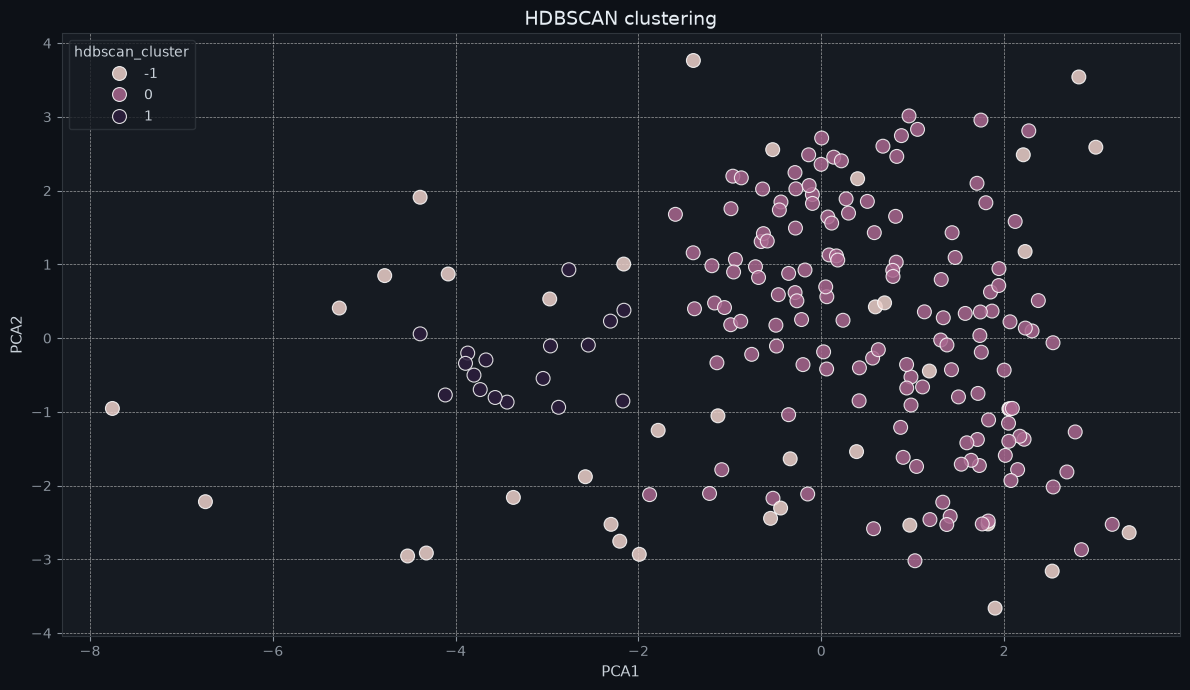

In [9]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=X_pca_df,
    x="PCA1",
    y="PCA2",
    hue="hdbscan_cluster",
    s=100,
    alpha=0.85
)
plt.title("HDBSCAN clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()